<font size=10>**TASK 1 - MULTILABEL TEXT CLASSIFICATION**</font> <a class="anchor" id='title'></a> 

**Bachelor's in Data Science - NOVA IMS (25/26)**

**Project**: *Straining the great southern Melting Pot*

**Group 8**
- Beatriz Marques 20231605
- David Carrilho 20231693
- Duarte Fernandes 20231619
- Filipe Caçador 20231707
- Mariana Calais-Pedro 20231641

*«notebook description»*

**Question**: *How well can we classify a restaurant’s cuisine type using the content of their reviews as input?*

<font color='#BFD72' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a> 
- [1. Imports](#P1)
- [2. Data](#P2)
- [3. Multilabel Classification](#P3)
    - [3.1 Specific Data Preparation](#P3.1)
    - [3.2 Model Implementation](#P3.2)
    - [3.3 Model Evaluation](#P3.3)

# <font color='#BFD72F' size=6>**1. Imports**</font> <a class="anchor" id="P1"></a>

[Back to TOC](#toc)

In [3]:
import warnings
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import sys
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from nltk.tokenize import PunktSentenceTokenizer
sent_tokenizer = PunktSentenceTokenizer()
import matplotlib.pyplot as plt
import plotly as px
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Get the absolute path of the source_code folder
source_code_path = os.path.abspath('../source')

# Add the source_code folder to sys.path
if source_code_path not in sys.path:
    sys.path.append(source_code_path)

from my_utils import *
from visualizations import *
from general_preprocessing import *

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


# <font color='#BFD72F' size=6>**2. Data**</font> <a class="anchor" id="P2"></a>
  
[Back to TOC](#toc)

In [5]:
dataset_original = load_dataset('../data/atlanta_restaurant_slice_2023.csv')

In [6]:
dataset_original.head()

,title,categoryName,website,url,reviewsCount,stars,text
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr..."
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...


In [7]:
dataset_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53566 entries, 0 to 53565
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         53566 non-null  object 
 1   categoryName  53566 non-null  object 
 2   website       50600 non-null  object 
 3   url           53566 non-null  object 
 4   reviewsCount  53566 non-null  int64  
 5   stars         53566 non-null  float64
 6   text          53566 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.9+ MB


| 🏷️ **Column Name** | 📝 **Description** |
|:-------------------|:-------------------|
|**title** | Name of the restaurant |
|**categoryName** | Labels that describe the restaurant's cuisine type |
|**website** | URL of the restaurant's webpage |
|**url** | URL of the restaurant's Google Maps page |
|**reviewsCount** | Total number of reviews for the restaurant at the time of scraping |
|**stars** | Customer rating (1 to 5) |
|**text** | Text of the review |

In [8]:
dataset = dataset_original.copy()

# <font color='#BFD72F' size=6>**3. Multilabel Classification**</font> <a class="anchor" id="P3"></a>
  
[Back to TOC](#toc)

## <font color='#BFD72F' size=6>3.1 Specific Data Preparation</font> <a class="anchor" id="P3.1"></a>
  
[Back to TOC](#toc)

In [9]:
dataset['cleaned_review_body'] =\
    dataset['text'].map(
    lambda content: main_pipeline(content,
        print_output = False,
        no_stopwords=True,            # Keep stopwords
        stopwords_tokeep=[],
        extra_stopwords=["food", "great", "good", "service", "place"],
        convert_diacritics=True,      
        lowercase=True,                
        lemmatized=True,              # Helps reduce vocabulary
        list_pos=[],           
        stemmed=False,
        pos_tags_list='no_pos',
        tokenized_output=False,
        no_emojis=True,               
        no_hashtags=True,              
        hashtag_retain_words=False,
        no_newlines=True,
        no_urls=True,
        no_punctuation=True,          
        treat_repeated_chars=True # "soooo good" → "soo good"
    )
)

In [10]:
dataset[['text', 'cleaned_review_body']].iloc[49].values

array(['Was just there to pick a friend up. Nice clean modern environment. Parking was tight but worth it. Will come back for entree',
       'pick friend nice clean modern environment parking tight worth come back entree'],
      dtype=object)

In [11]:
vectorizer = CountVectorizer(max_df=0.8, min_df=5)

X = vectorizer.fit_transform(dataset['cleaned_review_body'])
words = vectorizer.get_feature_names_out()

category_word_freq = []

for cat in dataset['categoryName'].unique():
    texts = dataset[dataset['categoryName'] == cat]['cleaned_review_body']
    X_cat = vectorizer.transform(texts)
    counts = X_cat.sum(axis=0).A1
    freq = dict(zip(words, counts))
    top_words = Counter(freq).most_common(15)  # top 15 per category

    for word, count in top_words:
        category_word_freq.append({'category': cat, 'word': word, 'count': count})


df_freq = pd.DataFrame(category_word_freq)
df_freq.head(15)


,category,word,count
0,Seafood restaurant,seafood,350
1,Seafood restaurant,back,346
2,Seafood restaurant,shrimp,337
3,Seafood restaurant,time,321
4,Seafood restaurant,delicious,248
5,Seafood restaurant,restaurant,245
6,Seafood restaurant,amazing,228
7,Seafood restaurant,fish,226
8,Seafood restaurant,excellent,215
9,Seafood restaurant,nice,202


In [12]:
fig = px.treemap(
    df_freq,
    path=[px.Constant('Atlanta Restaurants'), 'category', 'word'],  # Hierarquia
    values='count',
    color='count',
    color_continuous_scale='viridis',
    title='Most frequent words per cuisine category in Atlanta restaurant reviews'
)

fig.update_layout(
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.show()

In [13]:
## Create dummy columns to assess msg_len and nr_sents

dataset["msg_len"] = dataset["cleaned_review_body"].map(lambda content : len(str(content)))
dataset["sents"] = dataset["cleaned_review_body"].map(lambda content :\
                                                                  sent_tokenizer.tokenize(str(content)))
dataset["nr_sents"] = dataset["sents"].map(lambda content : len(content))

In [14]:
dataset.describe()
#is there reviews with 0 on len and 0 sentences?

,reviewsCount,stars,msg_len,nr_sents
count,53566.000000,53566.000000,53566.000000,53566.000000
mean,917.447355,4.050498,108.640518,0.975003
std,1129.721892,1.448570,144.587585,0.164956
min,5.000000,1.000000,0.000000,0.000000
25%,404.000000,3.000000,25.000000,1.000000
50%,644.000000,5.000000,62.000000,1.000000
75%,1051.250000,5.000000,136.000000,1.000000
max,13268.000000,5.000000,2722.000000,7.000000


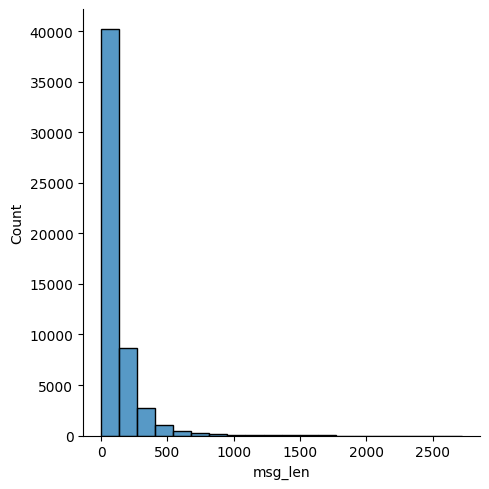

In [15]:
sns.displot(dataset["msg_len"], log_scale=False, bins=20)

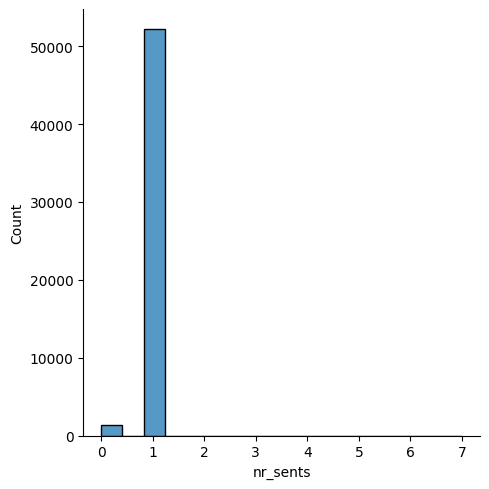

In [16]:
sns.displot(dataset["nr_sents"])

In [17]:
dataset

,title,categoryName,website,url,reviewsCount,stars,text,cleaned_review_body,msg_len,sents,nr_sents
0,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,"One word amazing!! The red fish, halibut, fr...",one word amazing red fish halibut fried rice b...,106,[one word amazing red fish halibut fried rice ...,1
1,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,First time here and the food is great and the ...,first time waiter excellent,27,[first time waiter excellent],1
2,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,I recently had the pleasure of dining at Optim...,recently pleasure dining optimist atlanta ga l...,1350,[recently pleasure dining optimist atlanta ga ...,1
3,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,Beautiful atmosphere and delicious food. All o...,beautiful atmosphere delicious wasnt flavorful...,229,[beautiful atmosphere delicious wasnt flavorfu...,1
4,The Optimist,Seafood restaurant,https://www.theoptimistrestaurant.com/,https://www.google.com/maps/place/The+Optimist...,3349,5.0,We had a wonderful dinner at the Optimist. Our...,wonderful dinner optimist group 9 meal oysters...,66,[wonderful dinner optimist group 9 meal oyster...,1
...,...,...,...,...,...,...,...,...,...,...,...
53561,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Friday night dinner was Chicken Francaise. Jor...,friday night dinner chicken francaise jordan e...,71,[friday night dinner chicken francaise jordan ...,1
53562,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Great dinner.... Yay Jordan!!!!!!,yay jordan,10,[yay jordan],1
53563,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was our server and he was fantastic! Gr...,jordan server fantastic meal,28,[jordan server fantastic meal],1
53564,L On North,New American restaurant,https://www.lonnorth.com/?utm_source=google&ut...,https://www.google.com/maps/place/L+On+North/@...,449,5.0,Jordan was an amazing server! Great delicious...,jordan amazing server delicious meal wine soci...,76,[jordan amazing server delicious meal wine soc...,1


In [18]:
## Extract the unique genres

unique_cuisine = []

for restaurants_cuisines in dataset["categoryName"]:
        if restaurants_cuisines not in unique_cuisine:
            unique_cuisine.append(restaurants_cuisines)

## Create a scratch dataset - "dataset_explore" - to plot the number of restaurants by category and to generate TF-IDF word clouds by label

dataset_explore = pd.DataFrame()
dataset_explore["cleaned_review_body"] = dataset["cleaned_review_body"]

for label in unique_cuisine:
    dataset_explore["has_label_{}".format(label)] = dataset["categoryName"].map(lambda labels_list : 1 if label in labels_list else 0)

## Assess the "dataset_explore" dataset

dataset_explore.describe()

,has_label_Seafood restaurant,has_label_Italian restaurant,has_label_Mexican restaurant,has_label_New American restaurant,has_label_Japanese restaurant,has_label_Fast food restaurant,has_label_American restaurant,has_label_Hamburger restaurant,has_label_Breakfast restaurant,has_label_Indian restaurant,has_label_Mediterranean restaurant,has_label_Thai restaurant,has_label_Steak house,has_label_Barbecue restaurant,has_label_Bar & grill,has_label_Chinese restaurant,has_label_Pizza restaurant,has_label_Chicken restaurant,has_label_Sandwich shop
count,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000,53566.000000
mean,0.038233,0.095359,0.167252,0.035526,0.028619,0.099410,0.129784,0.036945,0.046503,0.032726,0.027069,0.023522,0.033155,0.021263,0.020666,0.046373,0.085129,0.033230,0.034761
std,0.191761,0.293713,0.373204,0.185108,0.166734,0.299215,0.336069,0.188629,0.210575,0.177920,0.162287,0.151557,0.179044,0.144263,0.142265,0.210293,0.279076,0.179238,0.183175
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: >

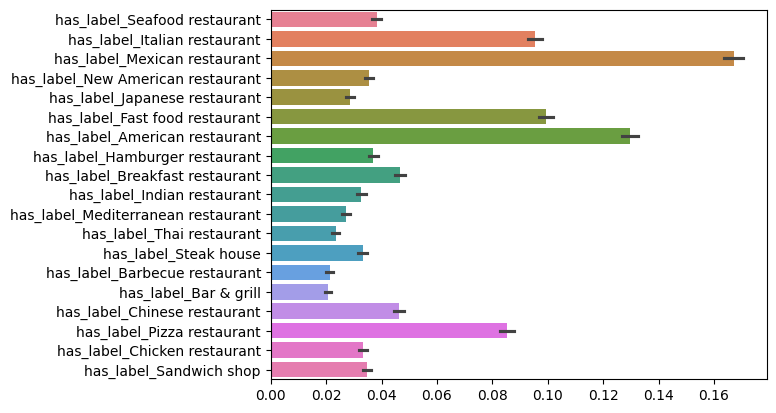

In [19]:
## Plot the number of movies by label

sns.barplot(dataset_explore, orient="h")

In [21]:
category_reviews = dataset.groupby("categoryName")["cleaned_review_body"].apply(lambda x: " ".join(x)).reset_index()

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(category_reviews["cleaned_review_body"])

similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=category_reviews["categoryName"],
    columns=category_reviews["categoryName"]
)

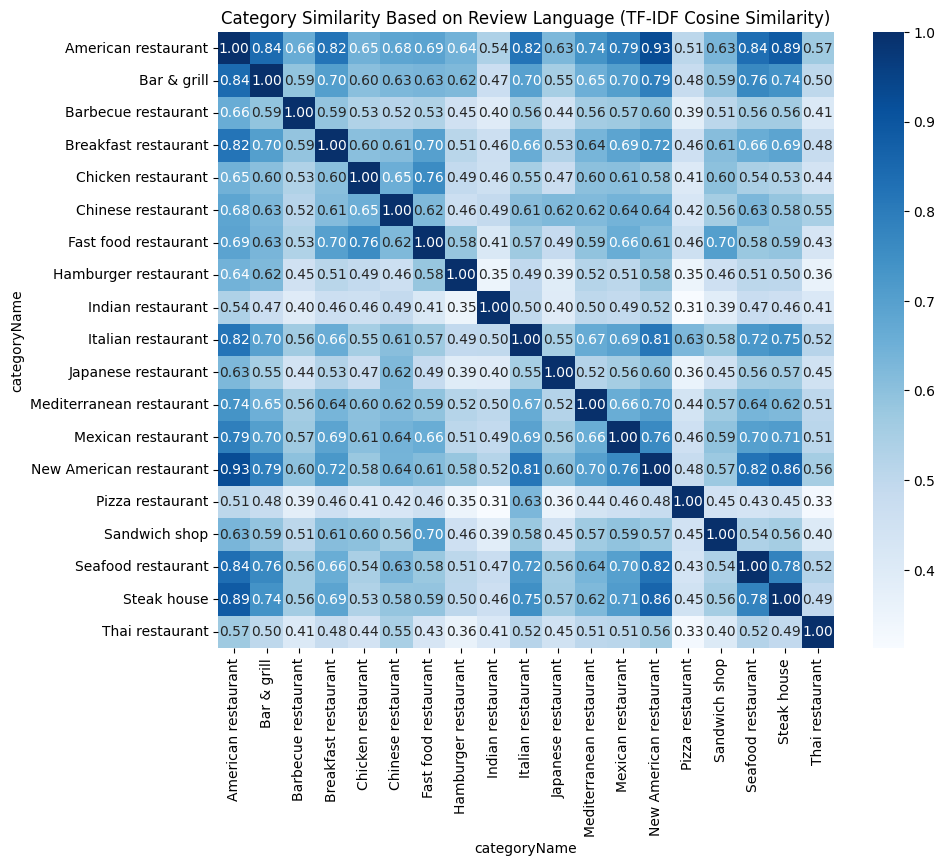

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_df, cmap="Blues", annot=True, fmt=".2f", square=True)
plt.title("Category Similarity Based on Review Language (TF-IDF Cosine Similarity)")
plt.show()

## <font color='#BFD72F' size=6>3.2 Model Implementation</font> <a class="anchor" id="P3.2"></a>
  
[Back to TOC](#toc)

## <font color='#BFD72F' size=6>3.3 Model Evaluation</font> <a class="anchor" id="P3.3"></a>
  
[Back to TOC](#toc)